# Imports

In [1]:
import pandas as pd
import json
import requests
import os
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

# Data Pull

## env variables

In [3]:
LAST_FM_URL = os.getenv("LAST_FM_URL")
LAST_FM_API_KEY = os.getenv("LAST_FM_API_KEY")

## my playlists

In [4]:
df = pd.read_json('Playlist1.json')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   playlists  189 non-null    object
dtypes: object(1)
memory usage: 1.6+ KB


In [6]:
# pd.set_option('display.max_colwidth', None)

In [7]:
df['playlists'][0]

{'name': "can't stress rn, too busy having fun",
 'lastModifiedDate': '2026-03-05',
 'collaborators': [],
 'items': [{'track': {'trackName': 'We Got the Party Duet with Jonas Brothers - Live from Arrowhead Pond, Anaheim, U.S.A./2008',
    'artistName': 'Hannah Montana',
    'albumName': 'Hannah Montana/Miley Cyrus: Best of Both Worlds Concert',
    'trackUri': 'spotify:track:6T7xieqFqFkWemSLvV30Ch'},
   'addedDate': '2026-03-05'},
  {'track': {'trackName': 'Silly',
    'artistName': 'Troye Sivan',
    'albumName': 'Something To Give Each Other',
    'trackUri': 'spotify:track:0Brx9I3vh7Po30gxsTtLz5'},
   'addedDate': '2026-03-05'}],
 'numberOfFollowers': 0}

In [8]:
df['playlists'][0]['items']

[{'track': {'trackName': 'We Got the Party Duet with Jonas Brothers - Live from Arrowhead Pond, Anaheim, U.S.A./2008',
   'artistName': 'Hannah Montana',
   'albumName': 'Hannah Montana/Miley Cyrus: Best of Both Worlds Concert',
   'trackUri': 'spotify:track:6T7xieqFqFkWemSLvV30Ch'},
  'addedDate': '2026-03-05'},
 {'track': {'trackName': 'Silly',
   'artistName': 'Troye Sivan',
   'albumName': 'Something To Give Each Other',
   'trackUri': 'spotify:track:0Brx9I3vh7Po30gxsTtLz5'},
  'addedDate': '2026-03-05'}]

In [9]:
df['playlists'][0]['items'][0]['track']

{'trackName': 'We Got the Party Duet with Jonas Brothers - Live from Arrowhead Pond, Anaheim, U.S.A./2008',
 'artistName': 'Hannah Montana',
 'albumName': 'Hannah Montana/Miley Cyrus: Best of Both Worlds Concert',
 'trackUri': 'spotify:track:6T7xieqFqFkWemSLvV30Ch'}

# get all playlist names

In [10]:
playlists = []

In [11]:
for playlist in df['playlists']:
    playlists.append(playlist['name'])

In [12]:
len(playlists)

189

In [13]:
playlists

["can't stress rn, too busy having fun",
 'the 28 club',
 'in the mood for love',
 'in my saturn return era',
 'on the pole',
 'year of the fire horse',
 'summer fun',
 'beatles',
 'breathe',
 'music with no words',
 'cool sexy mysterious',
 'cuntry',
 'delusionally optimistic',
 'N.Y. State of Mind',
 'smiling at my haters',
 'thangria en ethpaña',
 'sapphic queer girl summer',
 'lucy dacus setlist st paul',
 'one song from every album I want to buy a CD for',
 'fiesta',
 "party like it's 6pm",
 'folk',
 'gemini game',
 'sagittarius chaotic joy',
 'indie girl starter pack',
 'captions',
 "songs i'm listening to the year I turn 27",
 'main character',
 'indie pop rave',
 'rave latino',
 'songs i want in a video montage',
 'Minneapolis local music',
 '24 4 2',
 'spooky halloween',
 'old love songs',
 'pop princess',
 'The Beths 2023 setlist',
 '323',
 'Animal',
 'cool',
 "alex and i's wedding playlist",
 'family christmas party',
 'midwest emo fall vibes',
 'Midwest roadtrip',
 'I LOVE 

## remove embarrassing playlists

In [14]:
# playlists = playlists.remove('DRAKE')

# get all songs in playlists

In [15]:
songs = {}

In [16]:
for playlist in df['playlists']:
    for song in playlist['items']:
        artistName = song['track']['artistName']
        if song['track']['artistName'] in songs.keys():
            if song['track']['trackName'] in songs[artistName]:
                continue
            else:
                songs[artistName].append(song['track']['trackName'])
        else:
            songs[artistName] = [song['track']['trackName']]

In [17]:
len(songs)

2455

# get all songs from playlist

In [18]:
playlist_songs = {}
playlist_name = 'best random songs I know'

In [19]:
for playlist in df['playlists']:
    if playlist['name'] == playlist_name:
        for song in playlist['items']:
            artistName = song['track']['artistName']
            if song['track']['artistName'] in playlist_songs.keys():
                if song['track']['trackName'] in playlist_songs[artistName]:
                    continue
                else:
                    playlist_songs[artistName].append(song['track']['trackName'])
            else:
                playlist_songs[artistName] = [song['track']['trackName']]

In [20]:
len(playlist_songs)

96

In [21]:
first_key, first_value = next(iter(playlist_songs.items()))

In [22]:
print(first_key, first_value)

SALES ['Chinese New Year']


In [23]:
column_names = ["artist", "song_name", "song_tags", "artist_tags"]

In [24]:
df_playlist = pd.DataFrame(columns = column_names)

In [25]:
df_playlist.head()

,artist,song_name,song_tags,artist_tags


In [26]:
count = 0
song_rows = []
for artist, songs in playlist_songs.items():
    # get metadata for song-artist
    for song in songs:
        url = LAST_FM_URL

        # track top tags
        params = {
            'method': 'track.getTopTags',
            'artist': artist,
            'track': song,
            'api_key': LAST_FM_API_KEY,
            'format': 'json'
        }

        response = requests.get(url, params=params)
        # response.raise_for_status()
        
        if response.status_code == 200:
            result = response.json()
        #     print(result)
        #     if result.get('error'):
        #         print(f'Error message: {result.get("message")}')
        # else:
        #     print(f"API Error: Status Code {response.status_code}")
        #     print(response.text)

        song_tags_raw = result.get('toptags', {}).get('tag', [])

        # print(f"Top tags for {artist}'s {song}:")
        song_tags = {}
        for tag in song_tags_raw:
            song_tags[tag.get('name')] = tag.get('count')

        # artist top tags
        params = {
            'method': 'artist.getTopTags',
            'artist': artist,
            'track': song,
            'api_key': LAST_FM_API_KEY,
            'format': 'json' # Request response in JSON format
        }

        # Make the GET request
        response = requests.get(url, params=params)
        response.raise_for_status()
        result = response.json()
        artist_tags_raw = result.get('toptags', {}).get('tag', [])

        # print(f"Top tags for {artist}:")
        artist_tags = {}
        for tag in artist_tags_raw:
            artist_tags[tag.get('name')] = tag.get('count')

        # embed each artist-song
        # add to dataframe
        song_row = {
            'artist': artist,
            'song_name': song,
            'song_tags': song_tags,
            'artist_tags': artist_tags,
            # 'similar': similar
        }
        song_rows.append(song_row)
        # song_row = pd.Series([artist,song,song_tags,artist_tags])
        # df = pd.concat([df, song_row], ignore_index=True)
        count += 1
    # if count >= 5:
    #     break
df_playlist = pd.DataFrame(song_rows)


In [27]:
df_playlist.head(10)

,artist,song_name,song_tags,artist_tags
0,SALES,Chinese New Year,{},"{'Lo-Fi': 100, 'indie': 71, 'indie pop': 47, '..."
1,Tennis,Marathon,{},"{'indie pop': 100, 'Lo-Fi': 95, 'indie': 40, '..."
2,Dave B.,Outside,{},"{'Hip-Hop': 100, 'rap': 25, 'electronic': 17, ..."
3,The Score,Don't Wanna Wake Up,{},"{'rock': 100, 'alternative': 56, 'mod': 26, 'f..."
4,Sticky Fingers,These Girls,{},"{'indie': 100, 'australian': 100, 'rock': 55, ..."
5,Eden Project,Times Like These,{},"{'indie': 100, 'electronic': 100, 'USA': 66, '..."
6,Grizzly Bear,Two Weeks,"{'indie': 100, 'motherfuckin rabbits ejaculati...","{'indie': 100, 'experimental': 86, 'folk': 55,..."
7,Peter Bjorn and John,Young Folks,"{'indie': 100, 'indie pop': 73, 'swedish': 36,...","{'indie': 100, 'swedish': 82, 'indie pop': 50,..."
8,J-MAN,We Can Dance Now,{},{'electronica': 100}
9,Khalid,Location,"{'rnb': 100, 'soul': 100, 'alternative': 42, '...","{'soul': 100, 'pop': 96, 'rnb': 61, 'alternati..."


In [28]:
df_playlist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   artist       100 non-null    object
 1   song_name    100 non-null    object
 2   song_tags    100 non-null    object
 3   artist_tags  100 non-null    object
dtypes: object(4)
memory usage: 3.3+ KB


# embedding

In [29]:
EMBEDDING_MODEL = os.getenv("EMBEDDING_MODEL")

In [30]:
EMBEDDING_MODEL

'bge-m3'

# organize dataset of songs

In [29]:
df_artist = df_playlist.drop_duplicates(subset=['artist'])
df_artist = df_artist[['artist','artist_tags']]

In [30]:
# df_artist = df.groupby(['artist']).first()[['artist','artist_tags']]

In [31]:
df_artist.tail()

,artist,artist_tags
94,Danny Dwyer,"{'singer-songwriter': 100, 'indie': 100, 'hype..."
95,Omar Apollo,"{'rnb': 100, 'soul': 100, 'funk': 35, 'indie':..."
97,Hush Forte,"{'rnb': 100, 'Hip-Hop': 100, 'USA': 17, 'ameri..."
98,Choker,"{'rnb': 100, 'Hip-Hop': 100, 'alternative rnb'..."
99,Orion Sun,"{'Lo-Fi': 100, 'soul': 77, 'indie': 37, 'rnb':..."


## get metadata

# first try of clustering artists

In [32]:
cluster_artists_data = df_artist.to_dict(orient='records')

In [33]:
cluster_artists_data

[{'artist': 'SALES',
  'artist_tags': {'Lo-Fi': 100,
   'indie': 71,
   'indie pop': 47,
   'minimal rock': 12,
   'guitar pop': 2,
   'dream pop': 2,
   'american': 2,
   'minimal pop': 1,
   'bedroom pop': 1,
   'female vocalists': 1}},
 {'artist': 'Tennis',
  'artist_tags': {'indie pop': 100,
   'Lo-Fi': 95,
   'indie': 40,
   'chillwave': 36,
   'electronic': 13,
   'female vocalists': 8,
   'surf pop': 7,
   'Surf': 2,
   'dream pop': 2,
   'twee pop': 2}},
 {'artist': 'Dave B.',
  'artist_tags': {'Hip-Hop': 100, 'rap': 25, 'electronic': 17, 'hip hop': 17}},
 {'artist': 'The Score',
  'artist_tags': {'rock': 100,
   'alternative': 56,
   'mod': 26,
   'freakbeat': 17,
   'alt-rock': 2,
   'pop': 2,
   'USA': 2,
   'AOR': 1,
   'american': 1,
   'space-rock': 1}},
 {'artist': 'Sticky Fingers',
  'artist_tags': {'indie': 100,
   'australian': 100,
   'rock': 55,
   'Reggae Rock': 45,
   'alternative': 10,
   'indie rock': 7,
   'reggae': 2,
   'Disco': 1,
   'All': 1,
   'psychedeli

In [ ]:
# cluster_artists_data = [{"artist":i, "tags": t} for i,t in df_artist.iterrows()]

In [ ]:
# corpus = [d.values for d in cluster_artists_data]
# vectorizer = TfidfVectorizer()
# tfidf_matrix = vectorizer.fit_transform(corpus)

# # Feature names (vocabulary)
# print(vectorizer.get_feature_names_out())
artists = [d['artist'] for d in cluster_artists_data]
# tags = [d['artist_tags'].items() for d in cluster_artists_data]
tags = [item for d in cluster_artists_data for item in d['artist_tags'].keys()]
# all_tags = list(d.items())
# 2. Initialize and fit TfidfVectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(tags)

# 3. Create a DataFrame to view IDs alongside vectors
# get_feature_names_out() retrieves the word labels for each column
cluster_data = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
# cluster_data.insert(0, 'artists', artists)


In [43]:
cluster_data

,10s,60s,acoustic,aggrotech,all,alt,alternative,ambient,america,american,...,unidos,united,us,usa,vancouver,vinewood,vocalist,vocalists,vocals,york
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
667,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
669,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
print(vectorizer.get_feature_names_out())

['10s' '60s' 'acoustic' 'aggrotech' 'all' 'alt' 'alternative' 'ambient'
 'america' 'american' 'americana' 'angeles' 'aor' 'arab' 'arizona' 'art'
 'asian' 'australia' 'australian' 'avant' 'bass' 'bazzi' 'bc' 'beats'
 'bedroom' 'blogrebellen' 'blues' 'boston' 'boulevard' 'boyfriendz'
 'british' 'britpop' 'brockhampton' 'bubble' 'california' 'canada'
 'canadian' 'castelli' 'chicago' 'chillwave' 'china' 'classic' 'coast'
 'coitus' 'composition' 'country' 'dance' 'dark' 'deadman' 'diego' 'disco'
 'diy' 'downtempo' 'dream' 'dubstep' 'duo' 'east' 'ebm' 'electro'
 'electronic' 'electronica' 'electropop' 'eletronic' 'emo' 'ep' 'estados'
 'excellence' 'experimental' 'female' 'fi' 'folk' 'freak' 'freakbeat'
 'free' 'french' 'fun' 'funk' 'funk_add_to_lidarr_batch_22'
 'funk_add_to_lidarr_batch_3' 'funk_add_to_lidarr_batch_4'
 'funk_add_to_lidarr_batch_7' 'funk_add_to_lidarr_batch_9' 'future'
 'garage' 'garde' 'girl' 'girlband' 'go' 'goated' 'good' 'gothic' 'group'
 'groups' 'grunge' 'guitar' 'hard

In [47]:
from sklearn.cluster import KMeans

# 1. Define the model (choose number of clusters)
kmeans = KMeans(n_clusters=5, random_state=42)

# 2. Fit to your DataFrame
# Passing .values is generally faster than the DataFrame directly
cluster_labels = kmeans.fit_predict(cluster_data.values)

# 3. Add labels back to original data to visualize or analyze
# Assuming 'original_documents' is a list of your texts
df_results = pd.DataFrame({'tags': tags, 'cluster': cluster_labels})
print(df_results.head())


           tags  cluster
0         Lo-Fi        3
1         indie        0
2     indie pop        0
3  minimal rock        3
4    guitar pop        1


In [48]:
df_results

,tags,cluster
0,Lo-Fi,3
1,indie,0
2,indie pop,0
3,minimal rock,3
4,guitar pop,1
...,...,...
666,bedroom pop,1
667,Philadelphia,3
668,United States,3
669,Pennsylvania,3


use dictvectorizer, skip next code and reorder

In [ ]:
# G = nx.Graph()

In [ ]:
# for artist, artist_tags in df_artist.iterrows():
#     # G.add_node(artist, node_type='artist')
#     for artist_tag_name, artist_tag_count in artist_tags.items():
#         # G.add_node(artist_tag_name, node_type='tag')
#         G.add_edge(artist, artist_tag_name, weight=artist_tag_count)

In [ ]:
# plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [ ]:
# pos = nx.spring_layout(G, seed=42)

ValueError: could not convert string to float: 'SALES'

In [ ]:
# print(G.nodes()) 

[0, 'artist', 'artist_tags', 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99]


In [ ]:

# nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
# nx.draw_networkx_labels(G, pos, font_size=10)

# # Draw edges with varying thickness based on weight
# weights = [G[u][v]['weight']/20 for u, v in G.edges()] # Normalized for visualization
# nx.draw_networkx_edges(G, pos, width=weights)

# plt.title("Artist-Genre Knowledge Graph")
# plt.axis('off')
# plt.show()


In [83]:
v = DictVectorizer(sparse=False)
X = v.fit_transform(df_artist['artist_tags'])
artist_names = list(df_artist['artist'])
features = v.get_feature_names_out()

In [84]:
artist_names

['SALES',
 'Tennis',
 'Dave B.',
 'The Score',
 'Sticky Fingers',
 'Eden Project',
 'Grizzly Bear',
 'Peter Bjorn and John',
 'J-MAN',
 'Khalid',
 'The Revivalists',
 'Sir Sly',
 'San Cisco',
 'G.R.L.',
 'The Wrecks',
 'Tyrone Wells',
 'Hippo Campus',
 'GROUPLOVE',
 'Zerbin',
 'Bazzi',
 'Whethan',
 'Jessie Reyez',
 'lil aaron',
 'Ella Eyre',
 'Theory of a Deadman',
 'Amelia Moore',
 'Vinny Masino',
 'Clarence James',
 'M.A.G.S.',
 'HASANI',
 'Reaper',
 'Bakar',
 'Ameer Vann',
 'Burns Twins',
 'Eric Reprid',
 'Isaac Lewis',
 'TV Girl',
 'Felix Rabito',
 'mrmrs.',
 'Mosie',
 'Clueless Kit',
 'Born Without Bones',
 'Still Woozy',
 'Roland Faunte',
 'Maddie Barker',
 'Ambar Lucid',
 'Describer',
 'Breakup Shoes',
 'Jack Larsen',
 'Sisyfuss',
 'Will Trotman Band',
 'Havelock',
 'Thomas Headon',
 'Kenny Elrod',
 'marinelli',
 'Lady Denim',
 'Lofi Legs',
 'Victor Internet',
 'Pity Party (Girls Club)',
 'Dreamer Boy',
 'SWMRS',
 'Huron John',
 'JAWNY',
 'Elah Hale',
 'Banana Club',
 'sleep wel

In [85]:
features

array(['10s', '3', '60s', 'Aggrotech', 'All', 'Alt-country',
       'Arab excellence', 'Bc underground hip hop', 'California',
       'Canadian', 'China', 'Disco', 'Estados Unidos', 'French hip hop',
       'Garage Punk', 'Garage Rock', 'Girl Groups', 'Gothic', 'Grunge',
       'Harsh EBM', 'Hip-Hop', 'Jam', 'Jazz Rock', 'Khalid', 'Lo-Fi',
       'Lo-Fi Indie', 'Mellow', 'Minneapolis', 'Minnesota', 'Nashville',
       'Neo-Psychedelia', 'Neo-Soul', 'New Orleans', 'Pennsylvania',
       'Philadelphia', 'Pop RnB', 'Post Grunge', 'Psychedelic Rock',
       'Reggae Rock', 'Southern Rock', 'Surf', 'Sweden',
       'Theory Of A Deadman', 'UK', 'USA', 'United States', 'Vancouver',
       'acoustic', 'alt pop', 'alt-pop', 'alt-rock', 'alternative',
       'alternative hip hop', 'alternative hip-hop', 'alternative pop',
       'alternative rnb', 'alternative rock', 'ambient pop', 'america',
       'american', 'americana', 'arizona', 'art', 'art pop',
       'asian american hip hop', 'australia'

In [103]:
pca = PCA(n_components=10)
reduced_data = pca.fit_transform(X)

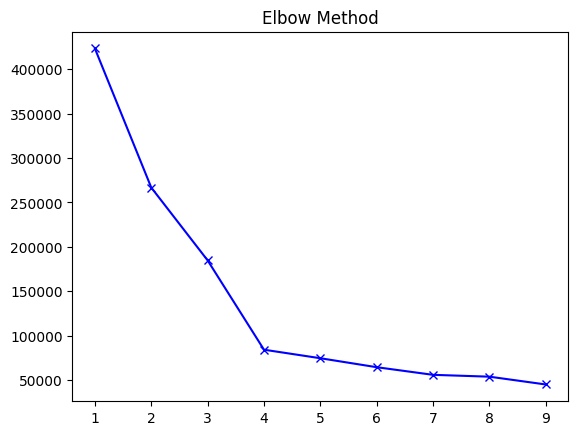

In [100]:
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(reduced_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, 'bx-')
plt.title('Elbow Method')
plt.show()

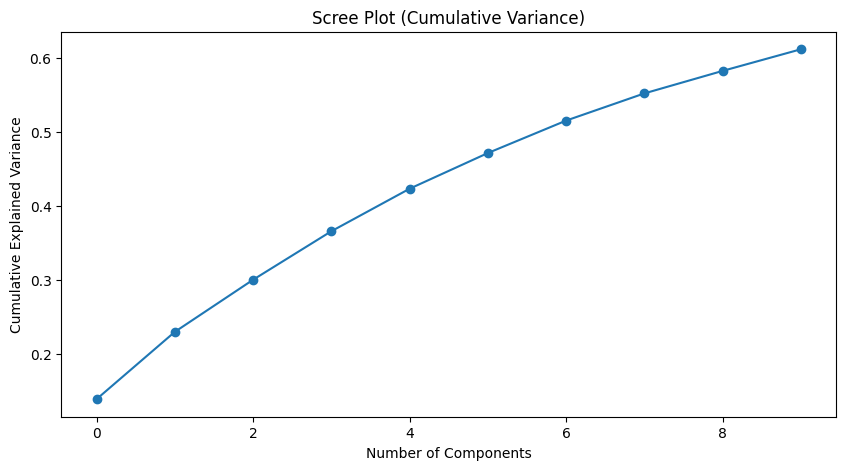

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot (Cumulative Variance)')
plt.show()

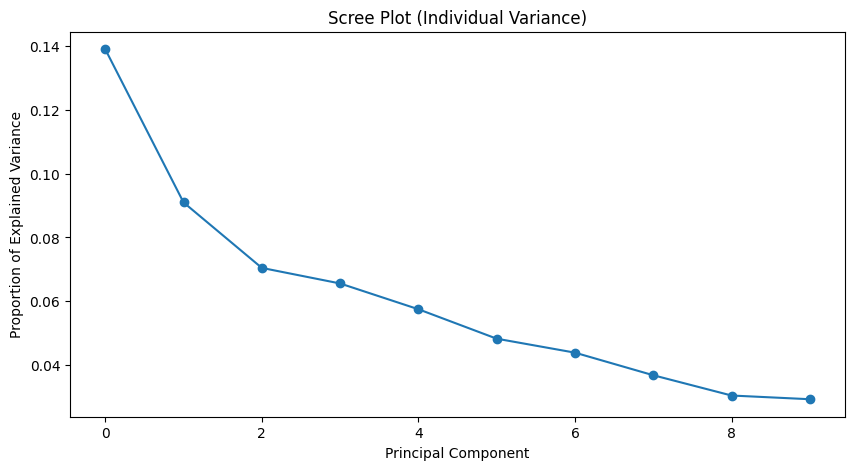

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Explained Variance')
plt.title('Scree Plot (Individual Variance)')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

In [99]:
df_result = pd.DataFrame(reduced_data, columns=['x', 'y', 'z'])
df_result['cluster'] = clusters
df_result['artist'] = artist_names

/Users/carladaza/Documents/vscode/carladaza.github.io/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 33853 (\N{CJK UNIFIED IDEOGRAPH-843D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/carladaza/Documents/vscode/carladaza.github.io/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/carladaza/Documents/vscode/carladaza.github.io/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39131 (\N{CJK UNIFIED IDEOGRAPH-98DB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/carladaza/Documents/vscode/carladaza.github.io/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36554 (\N{CJK UNIFIED IDEOGRAPH-8ECA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

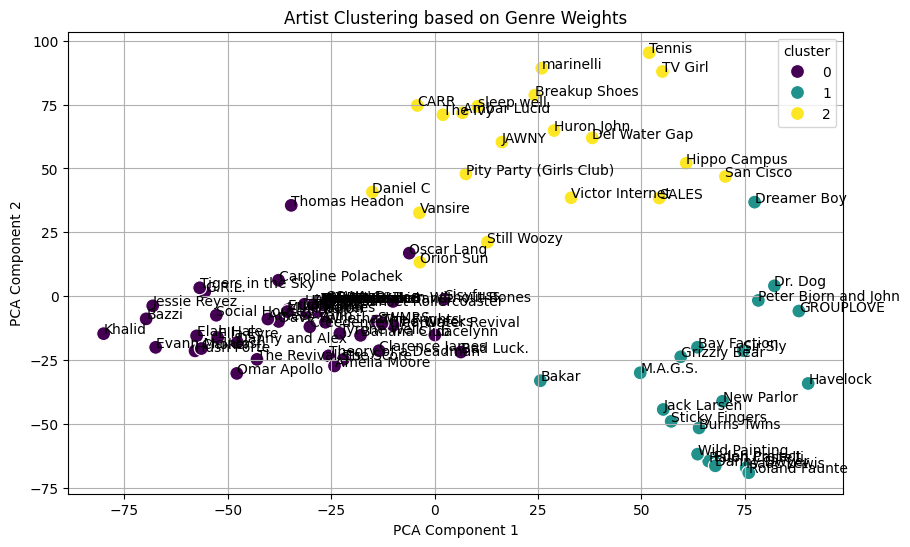

: 

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_result, x='x', y='y', z='z', hue='cluster', palette='viridis', s=100)

# Add labels
for i in range(len(df_result)):
    plt.text(df_result.x[i]+0.02, df_result.y[i], df_result.artist[i])

plt.title('Artist Clustering based on Genre Weights')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

In [93]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
# Find number of components for 90% variance
n_components = np.argmax(cumulative_variance >= 0.90) + 1

In [94]:
n_components

np.int64(1)

In [95]:
print(pca.explained_variance_ratio_) 

[0.13905573 0.09098645]


In [96]:
print(np.sum(pca.explained_variance_ratio_))

0.23004218336251545


In [ ]:
df_artist['artist'].nunique()

IndexError: Column(s) ['artist', 'artist_tags'] already selected

: 

In [40]:
len(df_artist)

5